# Utils

In [63]:
#
import os 
import pandas as pd
from datetime import datetime

RESULTS_FILE = "model_results_log.csv"

# generated by chatgpt
def log_result(
    model_name,
    params,
    mean_score,
    std_score=None,
    notes=None
):
    """
    Append a single experiment result to a CSV log.
    """
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "params": str(params),
        "mean_f1_macro": mean_score,
        "std_f1_macro": std_score,
        "notes": notes
    }

    df_row = pd.DataFrame([row])

    if os.path.exists(RESULTS_FILE):
        df_row.to_csv(RESULTS_FILE, mode="a", header=False, index=False)
    else:
        df_row.to_csv(RESULTS_FILE, mode="w", header=True, index=False)

    print(f"✔ Logged result for {model_name}")

# Data Rules

In [64]:
import numpy as np
def apply_rules(y_pred_probs, X_subset, classes):
    """
    Rule:
    - If patient expired (discharge_disposition_id in {11,19,20,21}),
      override prediction to 'NO'.

    X_subset: the feature DataFrame for the same rows as y_pred_probs
              (used to read one-hot discharge columns).
    classes: model.classes_ (order of columns in predict_proba)
    """
    y_pred_probs_adjusted = y_pred_probs.copy()

    # expired one-hot columns (safe if some are missing)
    EXPIRED_OHE_COLS = [
        "discharge_disposition_id_11",
        "discharge_disposition_id_19",
        "discharge_disposition_id_20",
        "discharge_disposition_id_21", 
    ]
    is_expired = (
        X_subset.reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
                .sum(axis=1)
                .to_numpy()
                .astype(bool)
    )

    # find which column corresponds to label "NO"
    classes = np.array(classes)
    no_idx = np.where(classes == "NO")[0][0]

    # force NO prob = 1.0 for expired rows
    y_pred_probs_adjusted[is_expired] = 0.0
    y_pred_probs_adjusted[is_expired, no_idx] = 1.0

    return y_pred_probs_adjusted

In [65]:
from sklearn.base import clone
from sklearn.metrics import f1_score, balanced_accuracy_score


def cross_validate_with_rules(model, X, y_str, cv, scoring, return_train_score=False):
    """
    Like cross_validate, but applies apply_rules(...) on predict_proba outputs.
    If return_train_score=True, also returns train_* keys.
    """
    results = {f"test_{k}": [] for k in scoring.keys()}
    if return_train_score:
        results.update({f"train_{k}": [] for k in scoring.keys()})

    for train_idx, test_idx in cv.split(X, y_str):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_str.iloc[train_idx], y_str.iloc[test_idx]

        m = clone(model)
        m.fit(X_train, y_train)

        # ---- TEST ----
        y_pred_probs_test = m.predict_proba(X_test)
        y_pred_probs_test_adj = apply_rules(y_pred_probs_test, X_test, m.classes_)
        y_pred_test = m.classes_[np.argmax(y_pred_probs_test_adj, axis=1)]

        # compute test metrics
        for name, scorer in scoring.items():
            if scorer == "accuracy":
                results[f"test_{name}"].append((y_pred_test == y_test.to_numpy()).mean())
            else:
                if name == "balanced_accuracy":
                    results[f"test_{name}"].append(balanced_accuracy_score(y_test, y_pred_test))
                elif name == "f1_macro":
                    results[f"test_{name}"].append(f1_score(y_test, y_pred_test, average="macro"))
                elif name == "f1_weighted":
                    results[f"test_{name}"].append(f1_score(y_test, y_pred_test, average="weighted"))
                else:
                    raise ValueError(f"Unsupported scoring key: {name}")
        if return_train_score:
            y_pred_probs_train = m.predict_proba(X_train)
            y_pred_probs_train_adj = apply_rules(y_pred_probs_train, X_train, m.classes_)
            y_pred_train = m.classes_[np.argmax(y_pred_probs_train_adj, axis=1)]

            for name, scorer in scoring.items():
                if scorer == "accuracy":
                    results[f"train_{name}"].append((y_pred_train == y_train.to_numpy()).mean())
                else:
                    if name == "balanced_accuracy":
                        results[f"train_{name}"].append(balanced_accuracy_score(y_train, y_pred_train))
                    elif name == "f1_macro":
                        results[f"train_{name}"].append(f1_score(y_train, y_pred_train, average="macro"))
                    elif name == "f1_weighted":
                        results[f"train_{name}"].append(f1_score(y_train, y_pred_train, average="weighted"))
                    else:
                        raise ValueError(f"Unsupported scoring key: {name}")

    # convert to numpy arrays
    for k in list(results.keys()):
        results[k] = np.array(results[k], dtype=float)

    return results

# 1 Cleaning Data

#### NOTE: We will not load test data here yet to prevent any accidental leakage

In [66]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
data_path = "../dataset/diabetic_data_training.csv"
train_df=pd.read_csv(data_path)
ids_mapping_path = "../dataset/IDS_mapping.csv"
ids_mapping = pd.read_csv(ids_mapping_path)

print("training data shape:", train_df.shape)
print("IDS mapping shape:", ids_mapping.shape)

print("training data")
display(train_df.head())

print("ids mapping")
display(ids_mapping.head())

training data shape: (91589, 50)
IDS mapping shape: (67, 2)
training data


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


ids mapping


,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available


## 1.1 Checking Target Distribution Balance

#### Note: If target distribution not balanced, for example 90% of people readmitted = "NO", the model might just learn to classify everybody as NO and have 90% accuraccy, which would be very bad

In [67]:
less_than_30 = 0
more_than_30 = 0
not_readmitted = 0
for _, row in train_df.iterrows():
    if row["readmitted"] == "NO":
        not_readmitted += 1
    elif row["readmitted"] == ">30":
        more_than_30 += 1
    else:
        less_than_30 += 1
print("<30:", less_than_30)
print(">30:", more_than_30)
print("NO:", not_readmitted)

<30: 10245
>30: 31989
NO: 49355


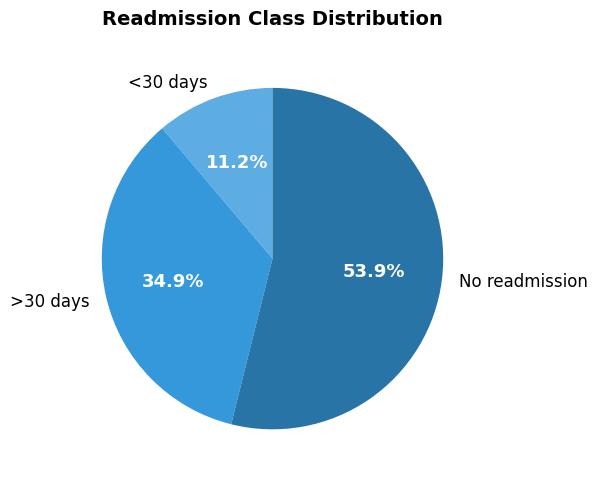

In [68]:
import matplotlib.pyplot as plt

# Get data
class_counts = train_df['readmitted'].value_counts().sort_index()
labels = ['<30 days', '>30 days', 'No readmission']  # Adjust as needed
values = class_counts.values

# Shades of blue
colors = ['#5dade2', '#3498db', '#2874a6']  # Light, Medium, Dark

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    values, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)

# Style percentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

# Add title
ax.set_title('Readmission Class Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('class_distribution.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

#### This means we an have uneven split of 1 : 3 : 5 and we have moderate class imbalance. This means we must be careful to make a balanced train - validation split. Also, when testing the performance of models, we must make sure to check for recall of the "<30" class to see if the model is catching that.

## 1.2. Train - Validation Split

#### We use the stratify option to ensure that the target variable distributions are the same in the train and val sets. We will use k-folds so nothing becessary to be done here yet

## 1.3. Missing Values

#### Some columns have a lot of values missing. For those, with missing values >70%, we could drop them as they are likely noise (and we can't really fill the values in with median / mode). However, what could potentially better is that we use a binary if that specific thing is relevnt or not (e.g., certain value might only be measured when it is relevant. So waiting for PCA to see if it is actually relevent.)

In [69]:
train_df = train_df.replace('?', np.nan)

missing_column_fraction = (train_df.isnull().sum() / len(train_df))

very_high_missing = missing_column_fraction[missing_column_fraction > 0.7].index.tolist()
high_missing = missing_column_fraction[(missing_column_fraction > 0.2) & (missing_column_fraction <= 0.7)].index.tolist()
low_missing = missing_column_fraction[(missing_column_fraction > 0) & (missing_column_fraction <= 0.2)].index.tolist()
no_missing = missing_column_fraction[missing_column_fraction == 0].index.tolist()

print("Very high missing (>0.7)", very_high_missing)
print("High missing (0.7 > x > 0.2)", high_missing)
print("Low missing (0.2 > x > 0)", low_missing)
print("No missing", no_missing)

Very high missing (>0.7) ['weight', 'max_glu_serum', 'A1Cresult']
High missing (0.7 > x > 0.2) ['payer_code', 'medical_specialty']
Low missing (0.2 > x > 0) ['race', 'diag_1', 'diag_2', 'diag_3']
No missing ['encounter_id', 'patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [70]:
# Because A1Cresult has significant medical relevance, we will keep the values even though a lot are missing
very_high_missing.remove("A1Cresult")
train_df['A1Cresult_not_recorded'] = train_df['A1Cresult'].isna().astype(int)

mapping = {
    'Norm': 1,
    '>7': 2,
    '>8': 3
}

train_df['A1Cresult_recorded'] = train_df['A1Cresult'].map(mapping).fillna(0).astype(int)
train_df.drop(columns=["A1Cresult"], inplace=True)


In [71]:
# For Very High Missing we create a binary column, whether the value has been recorded or not

for col in very_high_missing:
    train_df[col] = 1 - train_df[col].isnull().astype(int)
    train_df = train_df.rename(columns={col: f"is_{col}_recorded"})


# For High Missing we can create a new class of "Unknown", we don't need to create a seperate column to flag this is weird, as it will be
# correlated
for col in high_missing:
    train_df[col] = train_df[col].fillna("Unknown")


# For Low Missing we can reaplce with a median for numerical values, mode for non-numerical. For race, mode is reasonable because there 
# aren't many options, however, for daignoses we could do a new category unknown to not distort the distribution too much. Here we
# need a flag because we tell the model - we guessed that (for race). Fir diag we don't need, same principle as for high_missing
for col in ["diag_1", "diag_2", "diag_3"]:
    train_df[col] = train_df[col].fillna("Unknown")

train_df[f'is_{col}_interpolated'] = train_df[col].isnull().astype(int)
train_df["race"] = train_df["race"].fillna(train_df["race"].mode()[0])


## 1.4. Making sense of the Data

#### We will check whether numerical values should be considered as numerical - if they should be ordered or not

In [72]:
# We can drop columns like encounter_id - we can see in the feature table that they are not classified as features
train_df = train_df.drop("encounter_id", axis=1)

In [73]:
# Since age is actually an ordered column we will take the midpoint value + this should be an integer
def age_parser(age_string):
    bounds = age_string.strip("[]()").split("-")
    return (int(bounds[0]) + int(bounds[1])) // 2
train_df["age"] = train_df["age"].apply(lambda x: age_parser(x))


In [74]:
# If we check the IDS_mapping file we can see that the data in columns admission_type_id, discharge_disposition_id, admission_source_id
# shouldn't be ordered integers but strings - so we change them to strings and then do one-hot encoding
train_df["admission_type_id"] = train_df["admission_type_id"].astype(str)
train_df["admission_source_id"] = train_df["admission_source_id"].astype(str)
train_df["discharge_disposition_id"] = train_df["discharge_disposition_id"].astype(str)

In [75]:
int_cols = train_df.select_dtypes(include=['int', 'int64', 'int32']).columns.tolist()
print(int_cols)

['patient_nbr', 'age', 'is_weight_recorded', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'is_max_glu_serum_recorded', 'A1Cresult_not_recorded', 'A1Cresult_recorded', 'is_diag_3_interpolated']


In [76]:
# store original discharge_disposition_id values (as integers) before one-hot encoding
discharge_ids = train_df["discharge_disposition_id"].astype(int).values.copy()

## 1.5. Encoding into Numerical Values

#### Most models need numerical values so for columns with multiple options we can encode as binaries. However, we have to make sure we don't get an explosion of features. Hence we will use top N version of One-Hot-Encoding -> we will only do binary flags for most common N options

In [77]:
column_values = {}
for column in train_df.columns:
    unique_values = set(train_df[column])
    column_values[column] = unique_values
column_values

{'patient_nbr': {33947649,
  92667906,
  83623941,
  128319494,
  40763403,
  2752524,
  72351756,
  89391123,
  87031827,
  86507541,
  43515927,
  16121880,
  41287707,
  24117282,
  39583782,
  7471143,
  152698919,
  32899113,
  85196844,
  82968624,
  36438066,
  121372727,
  4849722,
  60031035,
  53870652,
  2621502,
  41287743,
  92274750,
  1835073,
  41680962,
  185991233,
  90701892,
  786501,
  57147462,
  64618560,
  24772680,
  95551560,
  87162957,
  88080462,
  44171343,
  38535246,
  67240017,
  43515990,
  9961560,
  61997148,
  112197726,
  111018078,
  59113566,
  5898339,
  112197735,
  23199849,
  47710314,
  24772716,
  21889134,
  96600177,
  2359413,
  20447352,
  102498426,
  524412,
  92536965,
  19136646,
  135,
  22937733,
  84410505,
  97648776,
  23724171,
  102236301,
  76021902,
  110231694,
  45613197,
  43909263,
  70254738,
  36044946,
  44957844,
  69992595,
  42074262,
  67633299,
  38011032,
  48758931,
  13107357,
  91357344,
  52297893,
  432554

In [78]:
# We first check whether columns are actually consistent - like having a column with 99% integers, 1% unknown or something would be bad

result = []

for col in train_df.columns:
    series = train_df[col]
    total = len(series)
    numeric_count = series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and not pd.isnull(x)).sum()
    string_count = series.apply(lambda x: isinstance(x, str)).sum()

    result.append({
        'Column': col,
        'Total': total,
        'Numeric': numeric_count,
        'String': string_count,
        'Type Breakdown': f"Strings: {string_count}, Numerics: {numeric_count}"
    })

breakdown_df = pd.DataFrame(result)
print(breakdown_df)


                       Column  Total  Numeric  String  \
0                 patient_nbr  91589    91589       0   
1                        race  91589        0   91589   
2                      gender  91589        0   91589   
3                         age  91589    91589       0   
4          is_weight_recorded  91589    91589       0   
5           admission_type_id  91589        0   91589   
6    discharge_disposition_id  91589        0   91589   
7         admission_source_id  91589        0   91589   
8            time_in_hospital  91589    91589       0   
9                  payer_code  91589        0   91589   
10          medical_specialty  91589        0   91589   
11         num_lab_procedures  91589    91589       0   
12             num_procedures  91589    91589       0   
13            num_medications  91589    91589       0   
14          number_outpatient  91589    91589       0   
15           number_emergency  91589    91589       0   
16           number_inpatient  

In [79]:
# Now we see that we have consistent - either all-strings or all-integer columns. Now we can do the top N encoding where necessary.
# Here we don't use the "weird" other binary, because it will be 100% correlated with the group Unknown
# Before choosing this arbitrary number 10, we should first look at how many times the column values repeat
# Actually, better than just choosing the value 10 would be to cpature 90% of the data, 10% is "Other"

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        freq_dict = train_df[col].value_counts().nlargest(500).to_dict()
        if len(freq_dict) > 10:
            print(f"Column: {col}")
            print(freq_dict)
            print("\n")

Column: discharge_disposition_id
{'1': 54187, '3': 12607, '6': 11589, '18': 3341, '2': 1893, '22': 1791, '11': 1475, '5': 1071, '25': 882, '4': 738, '7': 557, '23': 380, '13': 346, '14': 341, '28': 130, '8': 98, '15': 59, '24': 42, '9': 19, '17': 12, '16': 9, '19': 7, '10': 6, '27': 4, '12': 3, '20': 2}


Column: admission_source_id
{'7': 51839, '1': 26563, '17': 6099, '4': 2837, '6': 2035, '2': 982, '5': 759, '3': 172, '20': 147, '9': 115, '8': 15, '22': 12, '10': 8, '14': 2, '25': 2, '11': 1, '13': 1}


Column: payer_code
{'Unknown': 36247, 'MC': 29160, 'HM': 5658, 'SP': 4522, 'BC': 4167, 'MD': 3193, 'CP': 2281, 'UN': 2209, 'CM': 1737, 'OG': 930, 'PO': 530, 'DM': 490, 'CH': 132, 'WC': 126, 'OT': 83, 'MP': 70, 'SI': 53, 'FR': 1}


Column: medical_specialty
{'Unknown': 44992, 'InternalMedicine': 13191, 'Emergency/Trauma': 6808, 'Family/GeneralPractice': 6711, 'Cardiology': 4776, 'Surgery-General': 2783, 'Nephrology': 1445, 'Orthopedics': 1287, 'Orthopedics-Reconstructive': 1109, 'Radio

#### Literature Review for Feature Engineering

In [80]:
# Some nice sources that worked with the same dataset
# ICD - our idea was to just use the most common ones and the rest into other bucket (top N encoding)
# But then we also found in literature https://pmc.ncbi.nlm.nih.gov/articles/PMC3996476/pdf/BMRI2014-781670.pdf that
# we can group the diagnoses into 9 seperate groups - also by looking at the actual meaning od ICD
# Circulatory 390–459, 785 
# Respiratory 460–519, 786 
# Digestive 520–579, 787 
# Diabetes 250.xx 5,747 
# Injury 800–999 4,697 
# Musculoskeletal 710–739 
# Genitourinary 580–629, 788 
# Neoplasms 140–239 
# Other

In [81]:
diag_dict = (
    {a: "Circulatory" for a in range(390, 460)} |
    {785: "Circulatory"} |
    {b: "Respiratory" for b in range(460, 520)} |
    {786: "Respiratory"} |
    {c: "Digestive" for c in range(520, 580)} |
    {787: "Digestive"} |
    {250: "Diabetes"} |
    {d: "Injury" for d in range(800, 1000)} |
    {e: "Musculoskeletal" for e in range(710, 740)} |
    {f: "Genitourinary" for f in range(580, 630)} |
    {788: "Genitourinary"} |
    {g: "Neoplasms" for g in range(140, 240)} |
    {0: "Other"}
)

In [82]:
def is_int_convertible(string):
    try:
        int(string)
        return True
    except (ValueError, TypeError):
        return False

def diag_funct(diag_code):
    if is_int_convertible(diag_code):
        return int(diag_code)
    else:
        return 0

def map_funct(int_code):
    if int_code in diag_dict.keys():
        return diag_dict[int_code]
    else:
        return diag_dict[0]

train_df['diag_1'] = train_df['diag_1'].apply(diag_funct)
train_df['diag_2'] = train_df['diag_2'].apply(diag_funct)
train_df['diag_3'] = train_df['diag_3'].apply(diag_funct)

train_df['diag_1'] = train_df['diag_1'].apply(map_funct)
train_df['diag_2'] = train_df['diag_2'].apply(map_funct)
train_df['diag_3'] = train_df['diag_3'].apply(map_funct)

In [83]:
# Another useful paper: JMAI-24-70
# Discharge disposition ID and Admission_source_ID apparently extremely important - makes sense, in the feature table they have meaning
# Apparently discharge_disposition ID is extremely important, the most important feature as found in that paper

In [84]:
# Function to take first N so that captures X% of the data, however, some will have all encodings (discharge_disposition_id, admission_source_id)
ENCODE_ALL = ['diag_1', 'diag_2', 'diag_3', 'discharge_disposition_id', 'admission_source_id']
def get_top_n_to_cover_required_fraction(series, coverage=0.91):
    value_counts = series.value_counts()
    cumulative_frac = value_counts.cumsum() / len(series)
    top_categories = cumulative_frac[cumulative_frac <= coverage].index.tolist()
    
    return top_categories


for col in train_df.columns:
    if train_df[col].dtype == 'object' and col != "readmitted":
        if col in ENCODE_ALL:
            top_categories = train_df[col].unique().tolist()
        elif train_df[col].nunique() <= 10:
            top_categories = train_df[col].unique().tolist()
        else: 
            top_categories = get_top_n_to_cover_required_fraction(train_df[col], coverage=0.90)
            
        for value in top_categories:
            value_name = col + "_" + str(value)
            train_df[value_name] = (train_df[col] == value).astype(int)
        
        # If we have some left over, we make the Other column, meaning if we have more than 10
        if len(top_categories) < train_df[col].nunique():
            train_df[f"{col}_Other"] = (~train_df[col].isin(top_categories)).astype(int)

        # Also dropping the original not-numerical column
        train_df = train_df.drop(col, axis=1)

# We have to check if "Other" is even needed - can drop it if not
empty_cols = []
for col in train_df.columns:
    if (train_df[col] == 0).all():
        empty_cols.append(col)

train_df = train_df.drop(columns=empty_cols)  

# Also moving the target variable to the end for structure
cols = [col for col in train_df.columns if col != 'readmitted'] + ['readmitted']
train_df = train_df[cols]

/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_46087/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_46087/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_46087/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

In [85]:
data_path="diabetic_data_training.csv"
train_df.to_csv("clean_train_df.csv")

# 2. Feature Engineering

In [102]:
train_df = pd.read_csv("clean_train_df.csv")

### 2.1 Ablation Test for A1C

In [104]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

# Prepare data
X = train_df.drop(columns=["readmitted"])
y = LabelEncoder().fit_transform(train_df["readmitted"])

# Identify A1C features
a1c_cols = [col for col in X.columns if 'A1C' in col or 'a1c' in col.lower()]
print(f"A1C features found: {a1c_cols}\n")

# Create two feature sets
X_with_a1c = X
X_without_a1c = X.drop(columns=a1c_cols)

# Models WITH SCALING (using pipelines)
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1.0, max_iter=1000, random_state=42))  # Relaxed regularization
])

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True))
])

# 10-fold CV for Logistic Regression
print("="*60)
print("LOGISTIC REGRESSION - 10-Fold CV (Macro F1)")
print("="*60)
lr_with = cross_val_score(lr_pipeline, X_with_a1c, y, cv=10, scoring='f1_macro')
lr_without = cross_val_score(lr_pipeline, X_without_a1c, y, cv=10, scoring='f1_macro')

print(f"With A1C:    {lr_with.mean():.4f} (+/- {lr_with.std():.4f})")
print(f"Without A1C: {lr_without.mean():.4f} (+/- {lr_without.std():.4f})")
print(f"Difference:  {lr_with.mean() - lr_without.mean():.4f}\n")

# 10-fold CV for Neural Network
print("="*60)
print("NEURAL NETWORK - 10-Fold CV (Macro F1)")
print("="*60)
nn_with = cross_val_score(nn_pipeline, X_with_a1c, y, cv=10, scoring='f1_macro')
nn_without = cross_val_score(nn_pipeline, X_without_a1c, y, cv=10, scoring='f1_macro')

print(f"With A1C:    {nn_with.mean():.4f} (+/- {nn_with.std():.4f})")
print(f"Without A1C: {nn_without.mean():.4f} (+/- {nn_without.std():.4f})")
print(f"Difference:  {nn_with.mean() - nn_without.mean():.4f}\n")

# Summary
print("="*60)
print("SUMMARY (Macro F1)")
print("="*60)
print(f"LR improvement with A1C:  {(lr_with.mean() - lr_without.mean())*100:.2f}%")
print(f"NN improvement with A1C:  {(nn_with.mean() - nn_without.mean())*100:.2f}%")

A1C features found: ['A1Cresult_not_recorded']

LOGISTIC REGRESSION - 10-Fold CV (Macro F1)


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

With A1C:    0.3944 (+/- 0.0157)
Without A1C: 0.3947 (+/- 0.0158)
Difference:  -0.0003

NEURAL NETWORK - 10-Fold CV (Macro F1)


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

With A1C:    0.4059 (+/- 0.0233)
Without A1C: 0.4041 (+/- 0.0196)
Difference:  0.0018

SUMMARY (Macro F1)
LR improvement with A1C:  -0.03%
NN improvement with A1C:  0.18%


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

### 2.2 Correlation of Features with Target Variable

In [91]:
## Correlation of features with each target class (one-vs-rest)
from sklearn.preprocessing import LabelEncoder

X = train_df.drop(columns=["readmitted"])

# Fit LabelEncoder and get the correct class mapping
le = LabelEncoder()
y = le.fit_transform(train_df["readmitted"])

# Create correct class_names from the encoder (alphabetically sorted)
class_names = {i: label for i, label in enumerate(le.classes_)}
print(f"Correct encoding: {class_names}\n")

# Create correlation for each class
for class_label in [0, 1, 2]:
    # Create binary target (1 if this class, 0 otherwise)
    binary_target = (y == class_label).astype(int)
    
    # Compute correlation between each feature and this binary target
    correlations = X.corrwith(pd.Series(binary_target, index=X.index))
    
    # Sort by absolute correlation and take top 10
    top_10 = correlations.abs().sort_values(ascending=False).head(10)
    top_10_with_sign = correlations[top_10.index]
    
    print(f"\n{'='*60}")
    print(f"Top 10 Features Correlated with Readmission Class: {class_names[class_label]}")
    print(f"{'='*60}")
    print(top_10_with_sign.to_frame(name='Correlation'))

Correct encoding: {0: '<30', 1: '>30', 2: 'NO'}


Top 10 Features Correlated with Readmission Class: <30
                             Correlation
number_inpatient                0.167601
discharge_disposition_id_22     0.074718
discharge_disposition_id_1     -0.071973
number_emergency                0.060865
number_diagnoses                0.049593
discharge_disposition_id_11    -0.045404
time_in_hospital                0.044815
discharge_disposition_id_3      0.043515
num_medications                 0.039098
discharge_disposition_id_5      0.034865

Top 10 Features Correlated with Readmission Class: >30
                             Correlation
number_inpatient                0.115931
discharge_disposition_id_11    -0.093730
number_diagnoses                0.086344
number_outpatient               0.073728
patient_nbr                     0.071673
number_emergency                0.066742
admission_source_id_7           0.065587
admission_source_id_6          -0.055433
discharge_dispositi

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/nump

### 2.3. Multicollinearity

In [105]:
## Drop features with correlation >= 0.95

X = train_df.drop(columns=["readmitted"])
corr_matrix = X.corr()

# Find features to drop (keep first in each pair)
threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            # Drop the second feature in the pair
            to_drop.add(corr_matrix.columns[j])

print(f"Features to drop (|r| >= {threshold}): {len(to_drop)}")
print(f"\nFeatures being removed:")
for feat in sorted(to_drop):
    print(f"  - {feat}")

# Create cleaned dataframe
train_df_clean = train_df.drop(columns=list(to_drop))

print(f"\nOriginal features: {len(X.columns)}")
print(f"After removing multicollinear features: {len(train_df_clean.columns) - 1}")  # -1 for target
print(f"Features removed: {len(to_drop)}")

# Save the cleaned dataframe
train_df = train_df_clean


Features to drop (|r| >= 0.95): 16

Features being removed:
  - acarbose_Steady
  - acetohexamide_Steady
  - change_No
  - chlorpropamide_Steady
  - diabetesMed_No
  - gender_Male
  - glipizide-metformin_Steady
  - glyburide-metformin_Steady
  - metformin-pioglitazone_Steady
  - metformin-rosiglitazone_Steady
  - nateglinide_Steady
  - pioglitazone_Steady
  - rosiglitazone_Steady
  - tolazamide_Steady
  - tolbutamide_Steady
  - troglitazone_Steady

Original features: 187
After removing multicollinear features: 171
Features removed: 16


# 3. Trying Some Simple Models

### Logistic Regression to provide a justification for non-linear models

### To avoid data leakage:
 - scale within each fold
 -

In [28]:
train_df = pd.read_csv("../Dataset/clean_train_df.csv")

In [30]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

X = train_df.drop(columns=["readmitted"]) #all the input features (everything but the target which is readmitted column)
y = LabelEncoder().fit_transform(train_df["readmitted"]) #the target mapped into integers (no = 0, >30 = 1, <30 = 2)

# standardises the columns (makes them mean = 0, standard deviation = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
# Full Logistic Regression experiments from teammate - integrated safely into notebook
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

# Keep `cv` as 5-fold for compatibility with later kernel-methods cells
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Prepare data: reuse `train_df` already produced earlier in the notebook
X = train_df.drop(columns=["readmitted"])
y_str = train_df["readmitted"]      # string labels: 'NO', '>30', '<30'
y_enc = LabelEncoder().fit_transform(y_str)  # encoded labels for sklearn where needed

# ------------------
# (1) Single train/validation split (optional) - teammate's first cell
# ------------------
X_train, X_val, y_train_str, y_val_str = train_test_split(
    X,
    y_str,
    test_size=0.2,
    stratify=y_str,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression( solver="lbfgs", max_iter=500, class_weight="balanced" ))
])

pipeline.fit(X_train, y_train_str)

# post processing
y_pred_probs = pipeline.predict_proba(X_val)
y_pred_probs_adj = apply_rules(y_pred_probs, X_val, pipeline.classes_)
y_pred = pipeline.classes_[np.argmax(y_pred_probs_adj, axis=1)]

print("\nBalanced accuracy:", balanced_accuracy_score(y_val_str, y_pred))
print("Macro F1:", f1_score(y_val_str, y_pred, average="macro"))
print("\nConfusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_val_str, y_pred, labels=["NO", ">30", "<30"]))
print("\nClassification report:")
print(classification_report(y_val_str, y_pred, digits=4))

# ------------------
# (2) Cross-Validation: V1 - StandardScaler only (10-fold)
# ------------------
cv10 = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
model_v1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=500, class_weight="balanced"))
])
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1_macro": make_scorer(f1_score, average="macro"),
    "f1_weighted": make_scorer(f1_score, average="weighted")
}
cv_results_v1 = cross_validate_with_rules(model_v1, X, y_str, cv=cv10, scoring=scoring, return_train_score=False)

print("=== 10-Fold CV Logistic Regression Summary (V1) ===")
for metric in scoring.keys():
    scores = cv_results_v1[f"test_{metric}"]
    print(f"{metric}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

# ------------------
# (2) Cross-Validation: V2 - VarianceThreshold -> StandardScaler
# ------------------
model_v2 = Pipeline([
    ("low_var", VarianceThreshold(0.01)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.1, solver="lbfgs", max_iter=500, class_weight="balanced"))
])
cv_results_v2 = cross_validate_with_rules(model_v2, X, y_str, cv=cv10, scoring=scoring, return_train_score=True)

print("=== V2: 10-Fold CV Logistic Regression Summary ===")
for metric in scoring.keys():
    train_scores = cv_results_v2[f"train_{metric}"]
    val_scores = cv_results_v2[f"test_{metric}"]
    print( f"\n{metric}: Train mean ={train_scores.mean():.4f}, Train std ={train_scores.std():.4f} | Val mean ={val_scores.mean():.4f}, Val std ={val_scores.std():.4f}")

# ------------------
# (2) Cross-Validation: V3 - StandardScaler -> PCA
# ------------------
model_v3 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(C=0.1, solver="lbfgs", max_iter=500, class_weight="balanced"))
])
cv_results_v3 = cross_validate_with_rules(model_v3, X, y_str, cv=cv10, scoring=scoring, return_train_score=True)

print("=== V3: 10-Fold CV Logistic Regression with PCA Summary ===")
for metric in scoring.keys():
    train_scores = cv_results_v3[f"train_{metric}"]
    val_scores = cv_results_v3[f"test_{metric}"]
    print( f"\n{metric}: Train mean ={train_scores.mean():.4f}, Train std ={train_scores.std():.4f} | Val mean ={val_scores.mean():.4f}, Val std ={val_scores.std():.4f}")

# ------------------
# (2) Cross-Validation: V4 - Correlation-based filtering inside pipeline
# ------------------
from sklearn.base import BaseEstimator, TransformerMixin
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold
    def fit(self, X_df, y=None):
        corr = X_df.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self
    def transform(self, X_df):
        return X_df.drop(columns=self.to_drop_, errors="ignore")

model_v4 = Pipeline([
    ("corr_filter", CorrelationFilter(0.9)),
    ("low_var", VarianceThreshold(0.01)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(C=0.1, solver="lbfgs", max_iter=500, class_weight="balanced"))
])
cv_results_v4 = cross_validate_with_rules(model_v4, X, y_str, cv=cv10, scoring=scoring, return_train_score=True)

print("=== V4: 10-Fold CV Logistic Regression with Correlation Filter Summary ===")
for metric in scoring.keys():
    train_scores = cv_results_v4[f"train_{metric}"]
    val_scores = cv_results_v4[f"test_{metric}"]
    print( f"\n{metric}: Train mean ={train_scores.mean():.4f}, Train std ={train_scores.std():.4f} | Val mean ={val_scores.mean():.4f}, Val std ={val_scores.std():.4f}")

# ------------------
# Summary done - log one of the results (example: V4 val f1_macro)
# ------------------
log_result("LogisticRegression_V4_CorrFilter", {"C":0.1, "corr_threshold":0.9}, cv_results_v4['test_f1_macro'].mean(), cv_results_v4['test_f1_macro'].std(), notes="Correlation filter + VarianceThreshold + StandardScaler")

# Note: we intentionally left `cv` as 5-fold for later kernel-methods; cross-validation experiments used `cv10` (10-fold) to match teammate's analysis


Balanced accuracy: 0.45741464051542113
Macro F1: 0.43385816605208793

Confusion matrix (rows=true, cols=pred):
[[5826 2371 1674]
 [2266 2418 1714]
 [ 595  626  828]]

Classification report:
              precision    recall  f1-score   support

         <30     0.1964    0.4041    0.2643      2049
         >30     0.4465    0.3779    0.4094      6398
          NO     0.6707    0.5902    0.6279      9871

    accuracy                         0.4953     18318
   macro avg     0.4379    0.4574    0.4339     18318
weighted avg     0.5393    0.4953    0.5109     18318

=== 10-Fold CV Logistic Regression Summary (V1) ===
accuracy: Mean=0.4978, Std=0.0024
balanced_accuracy: Mean=0.4584, Std=0.0057
f1_macro: Mean=0.4349, Std=0.0035
f1_weighted: Mean=0.5124, Std=0.0020
=== V2: 10-Fold CV Logistic Regression Summary ===

accuracy: Train mean =0.4982, Train std =0.0009 | Val mean =0.4975, Val std =0.0029

balanced_accuracy: Train mean =0.4581, Train std =0.0009 | Val mean =0.4573, Val std =0.006

## Kernel Methods

In [32]:
import numpy as np
from sklearn.svm import SVC, LinearSVC
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# =========================
# 0) 10-fold CV
# =========================
cv10 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# =========================
# 1) FORCE encoded y (do NOT use whatever y is currently)
# =========================
le = LabelEncoder().fit(train_df["readmitted"])
y_enc = le.transform(train_df["readmitted"])  # ints 0..K-1

# we want the confusion matrix in this order, like your LogReg prints:
label_order = ["NO", ">30", "<30"]
label_order_idx = [int(le.transform([lab])[0]) for lab in label_order]
no_class_index = int(le.transform(["NO"])[0])

# =========================
# 2) Precompute expired mask once (from one-hot X)
# =========================
EXPIRED_OHE_COLS = [
    "discharge_disposition_id_11",
    "discharge_disposition_id_19",
    "discharge_disposition_id_20",
    "discharge_disposition_id_21",  # may not exist
]
expired_mask = (
    X.reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
     .sum(axis=1)
     .to_numpy()
     .astype(bool)
)

# =========================
# 3) Helpers: softmax + rule apply
# =========================
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    ez = np.exp(z)
    return ez / np.sum(ez, axis=1, keepdims=True)

def apply_rules_encoded(proba, is_expired, no_idx):
    proba_adj = proba.copy()
    proba_adj[is_expired] = 0.0
    proba_adj[is_expired, no_idx] = 1.0
    return proba_adj

# =========================
# 4) OOF evaluation (prints like logistic regression)
# =========================
def oof_eval_with_rules(model, X_mat, y_enc, expired_mask, cv, title="Model"):
    y_enc = np.asarray(y_enc, dtype=int)
    n = len(y_enc)
    oof_pred_enc = np.empty(n, dtype=int)

    fold_acc, fold_bal, fold_f1m, fold_f1w = [], [], [], []

    for tr, te in cv.split(X_mat, y_enc):
        m = clone(model)
        m.fit(X_mat[tr], y_enc[tr])

        # decision_function -> softmax -> rule -> argmax
        scores_raw = m.decision_function(X_mat[te])
        if scores_raw.ndim == 1:  # binary safety (unlikely here)
            scores_raw = np.vstack([-scores_raw, scores_raw]).T

        proba = softmax(scores_raw)
        proba_adj = apply_rules_encoded(proba, expired_mask[te], no_class_index)
        y_pred_te = np.argmax(proba_adj, axis=1)

        oof_pred_enc[te] = y_pred_te

        fold_acc.append(accuracy_score(y_enc[te], y_pred_te))
        fold_bal.append(balanced_accuracy_score(y_enc[te], y_pred_te))
        fold_f1m.append(f1_score(y_enc[te], y_pred_te, average="macro"))
        fold_f1w.append(f1_score(y_enc[te], y_pred_te, average="weighted"))

    print(f"\n================ {title} (10-fold OOF, WITH RULES) ================")
    print("OOF Balanced accuracy:", balanced_accuracy_score(y_enc, oof_pred_enc))
    print("OOF Macro F1:", f1_score(y_enc, oof_pred_enc, average="macro"))

    print("\nConfusion matrix (rows=true, cols=pred):")
    print(confusion_matrix(y_enc, oof_pred_enc, labels=label_order_idx))

    print("\nClassification report:")
    print(classification_report(
        y_enc,
        oof_pred_enc,
        labels=label_order_idx,
        target_names=label_order,
        digits=4
    ))

    print("\nPer-fold metrics (mean ± std):")
    print(f"accuracy:          {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f}")
    print(f"balanced_accuracy: {np.mean(fold_bal):.4f} ± {np.std(fold_bal):.4f}")
    print(f"f1_macro:          {np.mean(fold_f1m):.4f} ± {np.std(fold_f1m):.4f}")
    print(f"f1_weighted:       {np.mean(fold_f1w):.4f} ± {np.std(fold_f1w):.4f}")

    return float(np.mean(fold_f1m)), float(np.std(fold_f1m))


# =========================
# 5) LinearSVC (uses X_scaled)
# =========================
svm_linear = LinearSVC(class_weight="balanced", max_iter=5000)
print("svm linear setup done")

linear_mean, linear_std = oof_eval_with_rules(
    model=svm_linear,
    X_mat=X_scaled,
    y_enc=y_enc,
    expired_mask=expired_mask,
    cv=cv10,
    title="LinearSVC"
)

log_result(
    model_name="LinearSVC_with_rules",
    params={"class_weight": "balanced", "max_iter": 5000, "cv": 10},
    mean_score=linear_mean,
    std_score=linear_std,
    notes="10-fold OOF + decision_function softmax + expired->NO rule"
)

# =========================
# 6) RBF SVC + PCA (precompute PCA once)
# =========================
requested_components = 50
n_samples, n_features = X_scaled.shape
NUM_OF_COMPONENTS = max(1, min(requested_components, n_samples, n_features))
print("Using PCA components:", NUM_OF_COMPONENTS)

pca = PCA(n_components=NUM_OF_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

svm_rbf = SVC(
    kernel="rbf",
    gamma="scale",
    C=1.0,
    class_weight="balanced",
    cache_size=1000,
    decision_function_shape="ovr"
)

rbf_mean, rbf_std = oof_eval_with_rules(
    model=svm_rbf,
    X_mat=X_pca,
    y_enc=y_enc,
    expired_mask=expired_mask,
    cv=cv10,
    title=f"PCA{NUM_OF_COMPONENTS}+SVC_RBF"
)

log_result(
    model_name=f"PCA{NUM_OF_COMPONENTS}+SVC_RBF_with_rules",
    params={
        "pca_n_components": NUM_OF_COMPONENTS,
        "svm_kernel": "rbf",
        "svm_gamma": "scale",
        "svm_C": 1.0,
        "class_weight": "balanced",
        "cv": 10
    },
    mean_score=rbf_mean,
    std_score=rbf_std,
    notes="10-fold OOF + PCA(precomputed) + decision_function softmax + expired->NO rule"
)

svm linear setup done

================ LinearSVC (10-fold OOF, WITH RULES) ================
OOF Balanced accuracy: 0.4305000088295381
OOF Macro F1: 0.43167708161145474

Confusion matrix (rows=true, cols=pred):
[[38659  8369  2327]
 [18290 11224  2475]
 [ 5248  3385  1612]]

Classification report:
              precision    recall  f1-score   support

          NO     0.6216    0.7833    0.6931     49355
         >30     0.4885    0.3509    0.4084     31989
         <30     0.2513    0.1573    0.1935     10245

    accuracy                         0.5622     91589
   macro avg     0.4538    0.4305    0.4317     91589
weighted avg     0.5337    0.5622    0.5378     91589


Per-fold metrics (mean ± std):
accuracy:          0.5622 ± 0.0025
balanced_accuracy: 0.4305 ± 0.0023
f1_macro:          0.4317 ± 0.0027
f1_weighted:       0.5378 ± 0.0024
✔ Logged result for LinearSVC_with_rules
Using PCA components: 29

================ PCA29+SVC_RBF (10-fold OOF, WITH RULES) ================
OOF Bal

In [33]:
train_df["readmitted"].head()

0    >30
1     NO
2     NO
3     NO
4    >30
Name: readmitted, dtype: object

In [34]:
np.unique(y)[:10]

array([0, 1, 2])

## Neural Networks

In [35]:
import numpy as np
import tensorflow as tf 

keras = tf.keras


/Users/levondavtyan/repos/BENG0095_Coursework/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [77]:
target_column = "readmitted"

EXPIRED_OHE_COLS = [
    "discharge_disposition_id_11",
    "discharge_disposition_id_19",
    "discharge_disposition_id_20",
    "discharge_disposition_id_21",  
]

expired_mask_all = (
    train_df.drop(columns=[target_column], errors="ignore")
            .reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
            .sum(axis=1)
            .to_numpy()
            .astype(bool)
)

# label_map is: {'<30':0, '>30':1, 'NO':2}
NO_CLASS_INDEX = 2

def apply_rules_nn_probs(probs, expired_mask_subset):
    """
    probs: (n, 3) softmax probabilities
    expired_mask_subset: (n,) boolean mask for the same rows
    """
    probs_adj = probs.copy()
    probs_adj[expired_mask_subset] = 0.0
    probs_adj[expired_mask_subset, NO_CLASS_INDEX] = 1.0
    return probs_adj

#seperate features (X) and target (y)
X = train_df.drop(columns=[target_column])
y = train_df[target_column]

#convert to numpy arrays
X = X.to_numpy(dtype=np.float32)
y = y.to_numpy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print ("First 5 rows of X:\n", X[:5])
print ("First 5 values of y:\n", y[:5])

X shape: (91589, 29)
y shape: (91589,)
First 5 rows of X:
 [[ 0.  0.  0.  9.  0. 18.  1.  3. 59.  1.  0.  0.  0.  1.  0.  0.  0. 15.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 1.  0.  0.  6.  2. 13.  1.  2. 11.  1.  0.  0.  0.  1.  0.  0.  1. 25.
   0.  0.  0.  5.  0.  0.  0.  1.  0.  0.  1.]
 [ 0.  0.  0.  7.  0. 16.  1.  2. 44.  1.  0.  0.  0.  1.  0.  0.  0. 35.
   0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  5.  0.  8.  1.  1. 51.  1.  0.  0.  0.  1.  0.  0.  0. 45.
   0.  0.  0.  0.  0.  1.  1.  0.  0.  1.  0.]
 [ 0.  0.  0.  9.  0. 16.  0.  3. 31.  1.  0.  0.  0.  1.  0.  0.  0. 55.
   0.  0.  0.  6.  0.  1.  0.  0.  0.  0.  1.]]
First 5 values of y:
 ['>30' 'NO' 'NO' 'NO' '>30']


In [37]:
# encode labels to class indices
label_map = {'<30': 0, '>30': 1, 'NO': 2}
# apply the label map to the target array
y_idx = np.vectorize(label_map.get)(y)
print("y_idx shape:", y_idx.shape)
print("unique classes:", np.unique(y_idx))
# convert to categorical one-hot encoding
num_classes = 3
y_onehot= keras.utils.to_categorical(y_idx, num_classes=num_classes).astype(np.float32)
print("y_onehot shape:", y_onehot.shape)
print("First 5 rows of y_onehot:\n", y_onehot[:5])



y_idx shape: (91589,)
unique classes: [0 1 2]
y_onehot shape: (91589, 3)
First 5 rows of y_onehot:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [38]:
#normalise numeric features to enhace training stability. The standard score (z-score) normalization is applied here, with mean 0 and standard deviation 1.
# a small epsilon is added to the standard deviation to avoid division by zero.
eps=1e-8
X_mean = np.mean(X, axis=0, keepdims=True)
X_std = np.std(X, axis=0, keepdims=True)
X_norm = (X - X_mean) / (X_std + eps)
print("X standardized mean (first 5 features):", np.mean(X_norm, axis=0)[:5])
print("X standardized std (first 5 features):", np.std(X_norm, axis=0)[:5])

X standardized mean (first 5 features): [-2.6656108e-09 -2.0325283e-08  0.0000000e+00 -3.1987330e-08
  3.1987330e-08]
X standardized std (first 5 features): [0.9999999  0.9999998  0.99999994 1.         1.        ]


### Set K value for Cross Validation

K-1 folds for training and 1 fold for validation. Final performance will be the average over K runs. K=10 is used here, as, according to the lecture note, it is a standard default associated with low bias of validation error and acceptable computational cost.

In [39]:
from sklearn.model_selection import KFold
# 42 is a random seed for reproducibility
kf = KFold(n_splits=10, shuffle=True, random_state=42) 
folds=[]
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_norm)):
    folds.append((train_idx, val_idx))
    print(f"Fold {fold_idx}:" f"Train size ={len(train_idx)}," f"validation size = {len(val_idx)},")

Fold 0:Train size =82430,validation size = 9159,
Fold 1:Train size =82430,validation size = 9159,
Fold 2:Train size =82430,validation size = 9159,
Fold 3:Train size =82430,validation size = 9159,
Fold 4:Train size =82430,validation size = 9159,
Fold 5:Train size =82430,validation size = 9159,
Fold 6:Train size =82430,validation size = 9159,
Fold 7:Train size =82430,validation size = 9159,
Fold 8:Train size =82430,validation size = 9159,
Fold 9:Train size =82431,validation size = 9158,


# Activation Function + derivatives

In [40]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return np.where(x > 0, 1, 0)
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)
def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


### Defining the loss functions : Multiclass Cross-Entropy

🔶 **Change introduced:**

In [41]:

def cross_entropy_loss(y_true, y_pred, esp=1e-15):
    # parameters: Y_true: true labels in one-hot encoding, shape (m, num_classes)
    #             Y_pred: predicted logits (before softmax), shape (m, num_classes)
    #             esp: small value to avoid log(0)
    # m being the number of samples in one batch.
    m = y_true.shape[0]
    # apply softmax to convert logits to probabilities
    p = softmax(y_pred)
    # clip probabilities to avoid log(0)
    p = np.clip(p, esp, 1.0)
    log_likelihood = -np.log(p[range(m), np.argmax(y_true, axis=1)] + esp)
# compute the average cross-entropy loss
    loss = np.sum(log_likelihood) / m
    return loss
# quick test of the loss function, should be close to 1.0986 (ln(1/3)) for 3 classes with random predictions
y_test_true = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_test_pred = np.random.randn(3,3)
loss_test = cross_entropy_loss(y_test_true, y_test_pred)
print("Test cross-entropy loss (should be close to 1.0986):", loss_test)
print("y_onehot shape:", y_test_true.shape)


Test cross-entropy loss (should be close to 1.0986): 0.7973185016311058
y_onehot shape: (3, 3)


🔶 **Change introduced:**
Addition of the following code to define the class weights to improve the F1 Macro Score 

In [42]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

### Forward Propagation

In [43]:

def forward_propagation(X, weights, biases, activation_funcs):
    # X: input data, shape (m, n_features)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer
    a = X # a is the current activation and is needed for weight gradient calculation during backpropagation
    activations = [a]  # store activations for each layer
    zs = []  # store linear combinations (z) for each layer
    for W, b, activation in zip(weights, biases, activation_funcs): # the activation function is chosen based on the layer.
        z = np.dot(a, W) + b  # linear combination
        zs.append(z) # z is needed for derivative calculation during backpropagation
        # apply activation function
        if activation == 'sigmoid':
            a = sigmoid(z)
        elif activation == 'relu':
            a = relu(z)
        elif activation == 'leaky_relu':
            a = leaky_relu(z)
        elif activation == 'softmax':
            a = softmax(z)
        else:
            raise ValueError("Unsupported activation function")
        activations.append(a)
    return activations, zs

### 🔶 Metrics

- define how predictions will be interpreted using accuracy, precision, recall, F1 and confusion matrix

In [44]:
# add prediction to class helpers
def probs_to_labels(Y_probs): # convert predicted probabilities to class labels
    return np.argmax(Y_probs, axis=1)
def onehot_to_labels(Y_onehot): # convert one-hot encoded labels to class labels
    return np.argmax(Y_onehot, axis=1)

# add multiclass metrics (accuracy, precision, recall, F1-score)
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm
def precision_recall_f1_from_cm(cm):
    tp=np.diag(cm).astype(np.float32)
    fp=np.sum(cm, axis=0).astype(np.float32)-tp
    fn=np.sum(cm, axis=1).astype(np.float32)-tp
    support=np.sum(cm, axis=1).astype(np.float32)
    precision = np.divide(tp, tp + fp + 1e-15)
    recall = np.divide(tp, tp + fn + 1e-15)
    f1 = 2 * np.divide(precision * recall, precision + recall + 1e-15)
    return precision, recall, f1, support
def macro_weighted_avg(metric, support):
    macro = np.mean(metric)
    weighted = np.sum(metric * support) / (np.sum(support) + 1e-15)
    return macro, weighted
def multiclass_metrics(Y_true_onehot, Y_probs):
    y_true = onehot_to_labels(Y_true_onehot)
    y_pred = probs_to_labels(Y_probs)
    C = Y_true_onehot.shape[1]  # number of classes
    cm = confusion_matrix_np(y_true, y_pred, C)
    acc=float(np.mean(y_true == y_pred))
    precision_c, recall_c, f1_c, support_c = precision_recall_f1_from_cm(cm)
    precision_macro, precision_weighted = macro_weighted_avg(precision_c, support_c)
    recall_macro, recall_weighted = macro_weighted_avg(recall_c, support_c)
    f1_macro, f1_weighted = macro_weighted_avg(f1_c, support_c)
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "cm": cm,
        # NEW: per-class metrics (aligned with your one-hot class order)
        "precision_per_class": precision_c,
        "recall_per_class": recall_c,
        "f1_per_class": f1_c,
        "support_per_class": support_c
    }



### {Dimensionality Check}


The purpose is to:
- make sure the forward propagation works for both single samples and batches
- the batch dimension is preserved correctly across all layers.
- matrix multiplications and bias additions are consistent.
- the model is fully vectorised.

To do so, we need to test the forward propagation on:
1. A single input sample.
2. A batch of multiple samples.

He init is used for ReLu/Leaky ReLu to standardise the weight initialisation, preventing the associated exploding gradient issue.

In [45]:
# --- Case 1: Single input sample forward propagation test ---
print ("Single sample forward propagation test:")
weights = [np.random.randn(X_norm.shape[1], 64)*np.sqrt(2/X_norm.shape[1]),  # Input to hidden layer 1. Here, He initialization is used.
           np.random.randn(64, 32)*np.sqrt(2/64),                # Hidden layer 1 to hidden layer 2
           np.random.randn(32, num_classes)*np.sqrt(2/32)]       # Hidden layer 2 to output layer
biases = [np.random.randn(1, 64),    # Bias for hidden layer 1
          np.random.randn(1, 32),    # Bias for hidden layer 2
          np.random.randn(1, num_classes)]  # Bias for output layer
activation_funcs = ['relu', 'relu', 'softmax']  # Activation functions for each
a_test_single,_ = forward_propagation(X_norm[0:1], weights, biases, activation_funcs) #_ is the returned z values (zs) which are not used here.
for i, a in enumerate(a_test_single):
    print(f"Layer {i} activation shape: {a.shape}")
print("\n" +"-"*50 + "\n")
# --- Case 2: Batch input samples forward propagation test ---
print ("Batch samples forward propagation test:")
a_test_batch,_ = forward_propagation(X_norm[0:10], weights, biases, activation_funcs)
for i, a in enumerate(a_test_batch):
    print(f"Layer {i} activation shape: {a.shape}")

Single sample forward propagation test:
Layer 0 activation shape: (1, 29)
Layer 1 activation shape: (1, 64)
Layer 2 activation shape: (1, 32)
Layer 3 activation shape: (1, 3)

--------------------------------------------------

Batch samples forward propagation test:
Layer 0 activation shape: (10, 29)
Layer 1 activation shape: (10, 64)
Layer 2 activation shape: (10, 32)
Layer 3 activation shape: (10, 3)


In [46]:
# quick test of forward propagation, make sure it returns activations and zs.
a_test, z_test = forward_propagation(X_norm[0:2], weights, biases, activation_funcs)
print("Number of activation arrays returned:", len(a_test))
print("Number of z arrays returned:", len(z_test))

Number of activation arrays returned: 4
Number of z arrays returned: 3


### Create a derivative "lookup" helper

In [47]:
# create a derivative function map to facilitate backpropagation
def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def softmax_derivative(z):
    s = softmax(z)
    return s * (1 - s)
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

derivative_funcs = {
    'sigmoid': sigmoid_derivative,
    'relu': relu_derivative,
    'softmax': softmax_derivative,
    'leaky_relu': leaky_relu_derivative
}
# if we use softmax at output layer with cross-entropy loss, the derivative simplifies during backpropagation, so we don't need to compute it explicitly here.

### Define class weights

In [48]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

### Backpropagation Function

The aim of this section is to compute the gradient of the loss with respect to every trainable parameter (weights & biases) in the network.

Step 1: forward pass for all activations at every layer.

Step 2: initialise gradient containers.

Step 3: backprop at the output layer. 

Step 4: backprop through hidden layers using chain rule, divide by batch size to obtian the mean gradient.

In [49]:
def backpropagation(X,Y,weights, biases, activation_funcs, class_weights=None):
    # X: input data, shape (m, n_features)
    # Y: true labels in one-hot encoding, shape (m, num_classes)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer

    m = X.shape[0]  # number of samples in the batch

    # Step 1: forward pass to get activations and zs
    activations, zs = forward_propagation(X, weights, biases, activation_funcs)

    # Step 2: initialize gradients
    weight_grads = [np.zeros_like(W) for W in weights]
    bias_grads = [np.zeros_like(b) for b in biases]

    # Step 3: backpropagation at output layer
    delta = activations[-1] - Y  # derivative of loss w.r.t. output logits when using softmax + cross-entropy
    if class_weights is not None:
        y_idx = np.argmax(Y, axis=1)
        w = class_weights[y_idx]          # (m,)
        delta = delta * w[:, None]       # (m, C)


    # Step 4: backpropagation through hidden layers
    for l in range(len(weights)-2, -1, -1):
        z = zs[l]
        act_f = activation_funcs[l]
        delta = np.dot(delta, weights[l+1].T) * derivative_funcs[act_f](z)
        weight_grads[l] = np.dot(activations[l].T, delta) / m # mean over batch
        bias_grads[l] = np.sum(delta, axis=0, keepdims=True) / m # mean over batch

    return weight_grads, bias_grads

### Sense Check (dimensionality check for gradients)

In [50]:
print("Backpropagation gradient shape check:")
# single sample backpropagation test
w_grads_single, b_grads_single = backpropagation(X_norm[0:1], y_onehot[0:1], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_single, b_grads_single)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")
print("\n" +"-"*50 + "\n")
# batch sample backpropagation test
w_grads_batch, b_grads_batch = backpropagation(X_norm[0:10], y_onehot[0:10], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_batch, b_grads_batch)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")  

Backpropagation gradient shape check:
Layer 0 weight gradient shape: (29, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)

--------------------------------------------------

Layer 0 weight gradient shape: (29, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)


### Training

Aim  : build the structure of SGD (mini-batch) and 10-fold CV

Steps:

1. Write a training loop for ONE train/validation split and get it work end-to-end.

2. Wrap it in 10-fold cross-validation.

3. Tune hyperparameters (Ir, hidden sizes, epochs, batch size etc.)

In [51]:
# Compute class weights once per traning fold
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)

### Training with 10-fold cross-validation with random initialisation 

Neural networks optimise a non-convex objective, hence, different random initialisations can converge to different solutions.

To demonstrate this, the same network architecture is trained multiple times in each fold with different random seeds, and keep the run with the best validation loss.

### Random Initialisation 

In the following section, he_for_relu is used to switch between He and Xavier-style initialisation

In [52]:
# the default seeting is He initialisation for ReLU and Leaky ReLU activations.
def init_params (layer_sizes, seed=0,he_for_relu=True):
    rng=np.random.default_rng(seed) # create a local random number generator.
    weights=[] # shape (fan_in, fan_out)
    biases=[] # shape (1, fan_out)
    # iterate over consecutive layer sizes to create weight matrices and bias vectors.
    # fan_in: number of neurons feeding into the layer; fan_out: number of neurons in the next layer.
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]): 
        if he_for_relu:
            W = rng.normal(0, np.sqrt(2/fan_in), size=(fan_in, fan_out))
        else:
            W = rng.normal(0, np.sqrt(1/fan_in), size=(fan_in, fan_out))
        b = np.zeros((1, fan_out))
        weights.append(W.astype(np.float32))
        biases.append(b.astype(np.float32))
    return weights, biases

### Mini-Batch Generator (SGD)

In [53]:
# generator for mini-batches Stochastic Gradient Descent (SGD), optionally shuffles the data at each epoch.
def iterate_minibatches (X, Y, batch_size=256, shuffle = True, seed=0): 
    # X: input data, shape (num_samples, n_features)
    # Y: true labels in one-hot encoding, shape (num_samples, num_classes)
    num_samples = X.shape[0]
    indices = np.arange(num_samples) # shuffle indices instead of data to avoid modifying the original data.
    # randomly permute the order of samples to ensure each epoch sees data in different order.
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    # mini-batch loop
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples) # prevents index overflow and ensure all samples are used.
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], Y[batch_indices] # yield turns the function into a generator, it produces one batch at a time to make it memory efficient.

# Prediction + Accuracy Monitoring
def predict_probabilities(X, weights, biases, activation_funcs):
    activations, _ = forward_propagation(X, weights, biases, activation_funcs)
    return activations[-1]  # return output layer activations (probabilities)

def accuracy_from_onehot(Y_true_onehot, Y_pred_probs):
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_true_onehot, axis=1)
    return np.mean(Y_pred == Y_true)

### One training run on ONE fold (epochs + SGD + early stopping + weight decay)

Epoch = 50 and patience = 5, meaning the training can run for 50 epochs. It is aware that using epoch > 30 can lead to overfitting and increase validation loss - to prevent this, the validation loss is monitored and early stopping is applied where appropriate.

In [54]:
def train_one_run(X_train, Y_train, X_val, Y_val, layer_sizes, activation_funcs, act_f,
                  learning_rate=0.01, learning_rate_decay=0.001, weight_decay=0.0001, # L2 regularization coefficient
                  batch_size=256, max_epochs=50, 
                  early_stopping_patience=5, seed=0,verbose=False, he_for_relu=True, class_weights = None, class_weights_mode="train"):
    # initialize weights and biases
    weights, biases = init_params(layer_sizes, seed=seed, he_for_relu=he_for_relu)
    # compute class wieghts once from training labels only
    if class_weights is None and class_weights_mode=="train":
        class_weights = compute_class_weights_from_onehot(Y_train)
    else:
        class_weights = None
    best_val_loss = float('inf')
    best_weights = None
    best_biases = None
    epochs_without_improvement = 0
    history = []
    for epoch in range(1, max_epochs+1):
        lr_epoch = learning_rate / (1 + learning_rate_decay * epoch)  # decayed learning rate
        for Xb, Yb in iterate_minibatches(X_train, Y_train, batch_size=batch_size, shuffle=True, seed=seed+epoch):
            dW, db = backpropagation(Xb, Yb, weights, biases, act_f, class_weights=class_weights)
            # weight decay (L2 regularization)
            if weight_decay > 0:
                for i in range(len(dW)):
                    dW[i] += weight_decay * weights[i]
            weights = [W - lr_epoch * dW_i for W, dW_i in zip(weights, dW)]
            biases = [b - lr_epoch * db_i for b, db_i in zip(biases, db)]
        # end of one epoch

        # evaluate on train and validation after this epoch(use weighted loss for early stopping)
   
        train_probs = predict_probabilities(X_train, weights, biases, activation_funcs)
        val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
        
        train_loss = weighted_cross_entropy_from_onehot(Y_train, train_probs, class_weights=class_weights)
        val_loss = weighted_cross_entropy_from_onehot(Y_val, val_probs, class_weights=class_weights)
        
        train_acc = accuracy_from_onehot(Y_train, train_probs)
        val_acc = accuracy_from_onehot(Y_val, val_probs)
        
        history.append((train_loss, val_loss, train_acc, val_acc))

        if verbose:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # early stopping check (inside the epoch loop)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_weights = [W.copy() for W in weights]
            best_biases = [b.copy() for b in biases]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                    break

    # if no improvement was ever recorded, fall back to final weights
    if best_weights is None or best_biases is None:
        best_weights = weights
        best_biases = biases

    return best_weights, best_biases, history

### Per-class Evaluation and Cross-Validation Metrics

For each validation fold, class probabilities are predicted by the neural network and class labels are obtained via:

$$
\hat{y}_i = \arg\max_{c \in \{1,\dots,C\}} p_{i,c}
$$

where \( p_{i,c} \) denotes the predicted softmax probability for class \( c \).

From the resulting confusion matrix, **precision**, **recall**, and **F1-score** are computed for each class.  
Given the strong class imbalance in the dataset, **macro F1-score** is used as the primary optimisation metric:

$$
\mathrm{F1}_{\text{macro}} = \frac{1}{C} \sum_{c=1}^{C} \mathrm{F1}_c
$$



In [79]:
#create a fold evaluator 
def evaluate_fold(X_val, Y_val, weights, biases, activation_funcs, expired_mask_subset=None):
    val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)

    # apply post-processing rules ONLY for evaluation metrics
    if expired_mask_subset is not None:
        val_probs = apply_rules_nn_probs(val_probs, expired_mask_subset)

    m_val = multiclass_metrics(Y_val, val_probs)
    return m_val
def score_metrix(m):
    return m["f1_macro"]# return the macro F1-score as the primary metric

### Construction of the two outer loops: folds + random restarts

purpose: run a neural network with a fixed architecture, and evaluate it using:

1. K-fold cross validation (outer loop over folds)
2. Random restarts (inner loop over seeds) to reduce bad initialisation risk

In [81]:
# fixed architecture for "before tuning" demonstration
d_in = X_norm.shape[1]
n_classes = y_onehot.shape[1]
layer_sizes = [d_in, 64, 32, n_classes]
activation_funcs = ['relu', 'relu', 'softmax']  # using ReLU for hidden layers and softmax for output layer
seeds = [0, 1, 2]  # random seeds for restarts, which can lead to different minima.
fold_results = [] # to store best results from each fold

# outer loop over folds for K-Fold Cross Validation (CV),
# each fold uses a different split: train on K-1 folds, validate on 1 fold.
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
    X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

    class_weights = compute_class_weights_from_onehot(Y_train)

    best_run = None
    for seed in seeds:
        W, B, history = train_one_run(
            X_train, Y_train, X_val, Y_val,
            layer_sizes, activation_funcs,
            act_f=activation_funcs,
            learning_rate=0.01,
            learning_rate_decay=0.001,
            weight_decay=0.0001,
            batch_size=256,
            max_epochs=20,
            early_stopping_patience=5,
            class_weights=class_weights,   
            seed=seed,
            verbose=False,
            he_for_relu=True
        )
        
        best_val_loss = history[-1][1]  # extract the validation loss of the last epoch from history
        # keep only the restart(seed) that achieves the lowest val loss for this fold
        if (best_run is None) or (best_val_loss < best_run[0]):
            # store the current run's weights and biases (W, B)
            best_run = (best_val_loss, seed, W, B, history)
    fold_results.append(best_run)
    print(f"Fold {fold_idx:02d}: best_val_loss={best_run[0]:.4f} (seed={best_run[1]})")
# final fold metrics 
best_val_loss, best_seed, bestW, bestB, best_history = best_run

# compute cross-validation mean and std of validation loss across folds
cv_mean_loss=np.mean([result[0] for result in fold_results])
cv_std_loss=np.std([result[0] for result in fold_results])
print(f"10-Fold CV Mean Val Loss: {cv_mean_loss:.4f}, Std: {cv_std_loss:.4f}")

# evaluate on this fold's val set using the BEST weights/biases
m_val = evaluate_fold(
    X_val, Y_val,
    bestW, bestB,
    activation_funcs,
    expired_mask_subset=expired_mask_all[val_idx]
)

print(
    f"Fold {fold_idx:02d}: best_val_loss={best_val_loss:.4f} (seed={best_seed}) | "
    f"val_acc={m_val['accuracy']:.4f}, val_f1_macro={m_val['f1_macro']:.4f}, val_f1_weighted={m_val['f1_weighted']:.4f}"
)
# store fold-level metrics for later averaging 
fold_metrics = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB,activation_funcs, expired_mask_subset=expired_mask_all[val_idx]
)    
    fold_metrics.append({"fold": fold_idx, "seed": best_seed,
                         "val_loss": best_val_loss,
                         "val_accuracy": m_val['accuracy'],
                         "val_f1_macro": m_val['f1_macro'],
                         "val_f1_weighted": m_val['f1_weighted']})
    

val_losses=np.array([d["val_loss"] for d in fold_metrics], dtype=float)
val_accuracies=np.array([d["val_accuracy"] for d in fold_metrics], dtype=float)
val_f1_macros=np.array([d["val_f1_macro"] for d in fold_metrics], dtype=float)
val_f1_weighteds=np.array([d["val_f1_weighted"] for d in fold_metrics], dtype=float)

print("\n=== 10-fold CV Summary (best seed per fold)===")
print(f"Val Loss: Mean={np.mean(val_losses):.4f}, Std={np.std(val_losses):.4f}")
print(f"Val Accuracy: Mean={np.mean(val_accuracies):.4f}, Std={np.std(val_accuracies):.4f}")
print(f"Val F1 Macro: Mean={np.mean(val_f1_macros):.4f}, Std={np.std(val_f1_macros):.4f}")
print(f"Val F1 Weighted: Mean={np.mean(val_f1_weighteds):.4f}, Std={np.std(val_f1_weighteds):.4f}")

Fold 00: best_val_loss=0.8910 (seed=0)
Fold 01: best_val_loss=0.8823 (seed=0)
Fold 02: best_val_loss=0.8811 (seed=0)
Fold 03: best_val_loss=0.8876 (seed=2)
Fold 04: best_val_loss=0.8881 (seed=1)
Fold 05: best_val_loss=0.8797 (seed=2)
Fold 06: best_val_loss=0.8916 (seed=0)
Fold 07: best_val_loss=0.8949 (seed=0)
Fold 08: best_val_loss=0.8867 (seed=0)
Fold 09: best_val_loss=0.8929 (seed=0)
10-Fold CV Mean Val Loss: 0.8876, Std: 0.0049
Fold 09: best_val_loss=0.8929 (seed=0) | val_acc=0.5735, val_f1_macro=0.3765, val_f1_weighted=0.5169

=== 10-fold CV Summary (best seed per fold)===
Val Loss: Mean=0.8876, Std=0.0049
Val Accuracy: Mean=0.5779, Std=0.0032
Val F1 Macro: Mean=0.3832, Std=0.0044
Val F1 Weighted: Mean=0.5241, Std=0.0036


Since the main issue is imbalance, macro F1 is used as the main target.

To obtain robust performance estimates, per-class metrics are aggregated across all cross-validation folds and reported as **mean ± standard deviation**

In [57]:
#quick summary of per-class metrics over folds
def summarise_per_class_over_folds(fold_metrics, class_names):
    """
    fold_metrics: list of dicts (each dict is output of multiclass_metrics for a fold)
    class_names: list of class labels in the SAME order as one-hot encoding
    """
    C = len(class_names)

    P = np.array([m["precision_per_class"] for m in fold_metrics])  # (K, C)
    R = np.array([m["recall_per_class"]    for m in fold_metrics])  # (K, C)
    F = np.array([m["f1_per_class"]        for m in fold_metrics])  # (K, C)
    S = np.array([m["support_per_class"]   for m in fold_metrics])  # (K, C)

    summary = []
    for c in range(C):
        summary.append({
            "class": class_names[c],
            "precision_mean": float(np.mean(P[:, c])),
            "precision_std":  float(np.std(P[:, c], ddof=1)),
            "recall_mean":    float(np.mean(R[:, c])),
            "recall_std":     float(np.std(R[:, c], ddof=1)),
            "f1_mean":        float(np.mean(F[:, c])),
            "f1_std":         float(np.std(F[:, c], ddof=1)),
            "support":   float(np.mean(S[:, c]))
        })
    return summary


import pandas as pd

def print_per_class_summary(per_class_summary, title="Per-class mean ± std over folds"):
    rows = []
    for r in per_class_summary:
        rows.append({
            "Class": r["class"],
            "Precision (mean ± std)": f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
            "Recall (mean ± std)":    f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
            "F1 (mean ± std)":        f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
            "Support":                f"{r['support']:.1f}"
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {title} ===")
    display(df)


In [102]:
def per_class_table_from_fold_results(fold_results, folds, X_norm, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples like (best_val_loss, best_seed, bestW, bestB, best_history)
                 OR list of dicts containing weights/biases.
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results):
        # ---- support both tuple and dict formats ----
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
        else:
            # (best_val_loss, best_seed, bestW, bestB, best_history)
            bestW, bestB = fr[2], fr[3]

        _, val_idx = folds[fold_idx]
        X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

        m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
        fold_metrics_detailed.append(m_val)

    per_class_summary_untuned = per_class_table_from_fold_results(
    fold_results, folds, X_norm, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Untuned)"
)
    return per_class_summary_untuned


In [59]:
# compute per-class metrics over folds
class_names = ['<30', '>30', 'NO']  # ensure this matches the one-hot encoding order
fold_metrics_detailed = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
    fold_metrics_detailed.append(m_val)
per_class_summary_untuned = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary_untuned, title="Per-class mean ± std over folds (Untuned)")


=== Per-class mean ± std over folds (Untuned) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4049 ± 0.0574,0.0262 ± 0.0042,0.0491 ± 0.0076,1024.5
1,>30,0.4986 ± 0.0099,0.3235 ± 0.0095,0.3923 ± 0.0084,3198.9
2,NO,0.6031 ± 0.0030,0.8573 ± 0.0062,0.7081 ± 0.0033,4935.5


### Log the per-class metrics individually

In [60]:
# compute mean and std of fold macro-F1 scores (10-fold CV)
mean_f1_macro = float(np.mean(val_f1_macros))
std_f1_macro = float(np.std(val_f1_macros))

# Log the results using the provided logger (expected signature: log_result(name, mean_score, std_score))
log_result("Non-tuned Neural Network (64-32-relu, 10-fold CV)", mean_f1_macro, std_f1_macro)

✔ Logged result for Non-tuned Neural Network (64-32-relu, 10-fold CV)


### Stage 1: Tuning Hyper-Parameters 

Tune learning rate, weight decay and batch size

In [82]:
# run only one fold for hyperparameter tuning demonstration and shortlist top 2 best hyperparameters.
lrs = [0.01, 0.005]
weight_decays = [0, 0.0001, 0.001]
batch_sizes = [128, 256]

results=[]
for lr in lrs:
    for wd in weight_decays:
        for bs in batch_sizes:
            best_run = None
            for seed in seeds: # random restarts
                # call train_one_run with the correct parameter names (remove duplicate/unsupported kwargs)
                W, B, history = train_one_run(
                    X_train, Y_train, X_val, Y_val,
                    layer_sizes, activation_funcs,
                    act_f=activation_funcs,
                    learning_rate=lr,
                    learning_rate_decay=0.001,
                    weight_decay=wd,
                    batch_size=bs,
                    max_epochs=50,
                    class_weights=class_weights,   
                    early_stopping_patience=5,
                    seed=seed,
                    verbose=False,
                    he_for_relu=True
                )
                m_val = evaluate_fold(
                    X_val, Y_val,
                    W, B,
                    activation_funcs,
                    expired_mask_subset=expired_mask_all[val_idx]
                )
                metric_score = score_metrix(m_val)
                if (best_run is None) or (metric_score > best_run['metric_score']):
                    best_run = {"lr": lr, "weight_decay": wd, "batch_size": bs,
                                "seed": seed, "metric_score": metric_score,
                                "val_metrics": m_val,
                                "weights": W, "biases": B,
                                "history": history}
            results.append(best_run)
            print(f"lr={lr}, wd={wd}, bs={bs} -> best seed={best_run['seed']} | "
                  f"F1_macro={best_run['val_metrics']['f1_macro']:.3f} | "
                  f"F1_w={best_run['val_metrics']['f1_weighted']:.3f} | "
                  f"acc={best_run['val_metrics']['accuracy']:.3f}")

lr=0.01, wd=0, bs=128 -> best seed=1 | F1_macro=0.388 | F1_w=0.527 | acc=0.578
lr=0.01, wd=0, bs=256 -> best seed=2 | F1_macro=0.386 | F1_w=0.525 | acc=0.577
lr=0.01, wd=0.0001, bs=128 -> best seed=1 | F1_macro=0.388 | F1_w=0.527 | acc=0.578
lr=0.01, wd=0.0001, bs=256 -> best seed=1 | F1_macro=0.385 | F1_w=0.524 | acc=0.578
lr=0.01, wd=0.001, bs=128 -> best seed=1 | F1_macro=0.386 | F1_w=0.527 | acc=0.581
lr=0.01, wd=0.001, bs=256 -> best seed=1 | F1_macro=0.385 | F1_w=0.524 | acc=0.580
lr=0.005, wd=0, bs=128 -> best seed=2 | F1_macro=0.386 | F1_w=0.525 | acc=0.577
lr=0.005, wd=0, bs=256 -> best seed=1 | F1_macro=0.381 | F1_w=0.519 | acc=0.575
lr=0.005, wd=0.0001, bs=128 -> best seed=2 | F1_macro=0.384 | F1_w=0.525 | acc=0.578
lr=0.005, wd=0.0001, bs=256 -> best seed=1 | F1_macro=0.381 | F1_w=0.520 | acc=0.575
lr=0.005, wd=0.001, bs=128 -> best seed=1 | F1_macro=0.384 | F1_w=0.524 | acc=0.579
lr=0.005, wd=0.001, bs=256 -> best seed=1 | F1_macro=0.381 | F1_w=0.521 | acc=0.578


In [83]:
# select top 2 architectures for full CV based on F1_macro and loop them over 10 folds and calculte their metircs separately
# 1) pick top-2 configs from the previous tuning stage (assumes `results` exists)
results_sorted = sorted(results, key=lambda x: x["metric_score"], reverse=True)
top_results = results_sorted[:2]

all_top2_summaries = []   # store summary stats for config-1 and config-2
all_top2_fold_results = []  # store per-fold best models for each config (for optional later comparison)

for cfg_idx, res in enumerate(top_results, start=1):
    print(f"\n=== Full 10-Fold CV for Top Config {cfg_idx} ===")

    lr = res["lr"]
    wd = res["weight_decay"]
    bs = res["batch_size"]

    fold_metrics = []        # list of val_metrics dicts (one per fold)
    fold_results_this_config = []  # list of tuples (metric_score, seed, W, B, history) for this config

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

        # recompute class weights PER FOLD using training split only
        class_weights = compute_class_weights_from_onehot(Y_train)

        best_run = None  # IMPORTANT: reset per fold

        for seed in seeds:
            W, B, history = train_one_run(
                X_train, Y_train, X_val, Y_val,
                layer_sizes, activation_funcs,
                act_f=activation_funcs,
                learning_rate=lr,
                learning_rate_decay=0.001,
                weight_decay=wd,
                batch_size=bs,
                max_epochs=50,
                early_stopping_patience=5,
                class_weights=class_weights,
                seed=seed,
                verbose=False,
                he_for_relu=True
            )

            m_val = evaluate_fold(
                X_val, Y_val,
                W, B,
                activation_funcs,
                expired_mask_subset=expired_mask_all[val_idx]
            )
            metric_score = score_metrix(m_val)   # macro-F1 selector

            # keep best seed for THIS fold
            if (best_run is None) or (metric_score > best_run["metric_score"]):
                # copy arrays so they don't get overwritten later
                W_copy = [w.copy() for w in W]
                B_copy = [b.copy() for b in B]

                best_run = {
                    "val_metrics": m_val,
                    "metric_score": float(metric_score),
                    "seed": int(seed),
                    "weights": W_copy,
                    "biases": B_copy,
                    "history": history
                }

        # store fold-level best metrics for summary printing
        fold_metrics.append(best_run["val_metrics"])

        # store fold-level best model for later per-class report
        fold_results_this_config.append((
            best_run["metric_score"],
            best_run["seed"],
            best_run["weights"],
            best_run["biases"],
            best_run["history"]
        ))

        print(f"Fold {fold_idx:02d}: "
              f"F1_macro={best_run['val_metrics']['f1_macro']:.4f}, "
              f"F1_weighted={best_run['val_metrics']['f1_weighted']:.4f}, "
              f"Accuracy={best_run['val_metrics']['accuracy']:.4f}")

    # summarize across folds for THIS config
    f1_macros     = np.array([m["f1_macro"]     for m in fold_metrics], dtype=float)
    f1_weighteds  = np.array([m["f1_weighted"]  for m in fold_metrics], dtype=float)
    accuracies    = np.array([m["accuracy"]     for m in fold_metrics], dtype=float)

    summary = {
        "config_rank": cfg_idx,
        "lr": lr,
        "weight_decay": wd,
        "batch_size": bs,
        "f1_macro_mean": float(np.mean(f1_macros)),
        "f1_macro_std":  float(np.std(f1_macros, ddof=1)),
        "f1_weighted_mean": float(np.mean(f1_weighteds)),
        "f1_weighted_std":  float(np.std(f1_weighteds, ddof=1)),
        "acc_mean": float(np.mean(accuracies)),
        "acc_std":  float(np.std(accuracies, ddof=1)),
    }
    all_top2_summaries.append(summary)
    all_top2_fold_results.append(fold_results_this_config)

    print(f"Config {cfg_idx} Summary: "
          f"F1_macro Mean={summary['f1_macro_mean']:.4f}, Std={summary['f1_macro_std']:.4f}; "
          f"F1_weighted Mean={summary['f1_weighted_mean']:.4f}, Std={summary['f1_weighted_std']:.4f}; "
          f"Accuracy Mean={summary['acc_mean']:.4f}, Std={summary['acc_std']:.4f}")

# 2) choose the best config by mean macro-F1 across folds
best_cfg_idx = int(np.argmax([s["f1_macro_mean"] for s in all_top2_summaries]))  # 0 or 1
best_cfg_summary = all_top2_summaries[best_cfg_idx]

# 3) THIS is the one your later notebook sections should use
fold_results_tuned = all_top2_fold_results[best_cfg_idx]

print("\n=== Selected BEST config (from top-2) for downstream per-class reporting ===")
print(best_cfg_summary)
print("fold_results_tuned length:", len(fold_results_tuned))
assert len(fold_results_tuned) == len(folds)



=== Full 10-Fold CV for Top Config 1 ===
Fold 00: F1_macro=0.3987, F1_weighted=0.5351, Accuracy=0.5830
Fold 01: F1_macro=0.4053, F1_weighted=0.5422, Accuracy=0.5898
Fold 02: F1_macro=0.3972, F1_weighted=0.5404, Accuracy=0.5898
Fold 03: F1_macro=0.3953, F1_weighted=0.5385, Accuracy=0.5863
Fold 04: F1_macro=0.3944, F1_weighted=0.5384, Accuracy=0.5883
Fold 05: F1_macro=0.3912, F1_weighted=0.5360, Accuracy=0.5855
Fold 06: F1_macro=0.3896, F1_weighted=0.5292, Accuracy=0.5781
Fold 07: F1_macro=0.3922, F1_weighted=0.5331, Accuracy=0.5824
Fold 08: F1_macro=0.3924, F1_weighted=0.5345, Accuracy=0.5835
Fold 09: F1_macro=0.3878, F1_weighted=0.5268, Accuracy=0.5783
Config 1 Summary: F1_macro Mean=0.3944, Std=0.0051; F1_weighted Mean=0.5354, Std=0.0048; Accuracy Mean=0.5845, Std=0.0042

=== Full 10-Fold CV for Top Config 2 ===
Fold 00: F1_macro=0.3999, F1_weighted=0.5358, Accuracy=0.5828
Fold 01: F1_macro=0.4053, F1_weighted=0.5427, Accuracy=0.5900
Fold 02: F1_macro=0.3969, F1_weighted=0.5409, Accu

In [86]:
# log the best hyperparameter tuned model metrics into the provided logger
# Use the per-fold detailed metrics list (fold_metrics_detailed) which contains 'f1_macro' etc.
best_overall = top_results[0]  # select the best overall configuration

# use fold_metrics_detailed (per-fold dicts with keys like 'f1_macro') to compute statistics
f1_macros = np.array([m['f1_macro'] for m in fold_metrics_detailed])
f1_weighteds = np.array([m['f1_weighted'] for m in fold_metrics_detailed])
accuracies = np.array([m['accuracy'] for m in fold_metrics_detailed])

model_name = "NN_Custom_Tuned_Stage1"
mean_score = float(np.mean(f1_macros))
std_score = float(np.std(f1_macros, ddof=1))  # use sample std for reporting

params_tuned = {
    "arch": "64-32-relu, max_epochs=50",
    "lr": best_overall['lr'],
    "weight_decay": best_overall['weight_decay'],
    "batch_size": best_overall['batch_size']
}
notes = (f"Top Config: lr={best_overall['lr']}, "
         f"weight_decay={best_overall['weight_decay']}, "
         f"batch_size={best_overall['batch_size']}")

# call logger with the richer signature used elsewhere in the notebook
log_result(model_name, params_tuned, mean_score, std_score, notes=notes)

✔ Logged result for NN_Custom_Tuned_Stage1


The best-performing parameter values need to be fixed from this point

In [88]:
# fix training hyperparameters to the best configuration based on tuning results
# pick the best hyperparameters from tuning results
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
best_hyperparams = results_sorted[0]
best_lr = best_hyperparams['lr']
best_wd = best_hyperparams['weight_decay']
best_bs = best_hyperparams['batch_size']
print(f"\nBest Hyperparameters from Tuning: lr={best_lr}, weight_decay={best_wd}, batch_size={best_bs}")
# freeze them into one "fixed" dictionary for future reference
fixed_hyperparams = {
    "learning_rate": best_lr,
    "weight_decay": best_wd,
    "batch_size": best_bs
}
print("Fixed Hyperparameters for Future Runs:", fixed_hyperparams)


Best Hyperparameters from Tuning: lr=0.01, weight_decay=0.0001, batch_size=128
Fixed Hyperparameters for Future Runs: {'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 128}


### Summarise the performance across each class after hyper-parameter tuning

In [ ]:
def per_class_table_from_fold_results(fold_results_tuned, folds, X_norm, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples like (best_val_loss, best_seed, bestW, bestB, best_history)
                 OR list of dicts containing weights/biases.
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results_tuned):  
        # ---- support both tuple and dict formats ----
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
        else:
            # (best_val_loss, best_seed, bestW, bestB, best_history)
            bestW, bestB = fr[2], fr[3]

        _, val_idx = folds[fold_idx]
        X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

        m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
        fold_metrics_detailed.append(m_val)

    per_class_summary_tuned = per_class_table_from_fold_results(
    fold_results_tuned, folds, X_norm, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Stage-1 Tuned)"
)
    return per_class_summary_tuned


In [90]:
# print the per-class summary over folds (Tuned Model)
class_names = ['<30', '>30', 'NO']  # ensure matches one-hot order

fold_metrics_detailed_tuned = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results_tuned):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
    fold_metrics_detailed_tuned.append(m_val)

per_class_summary_tuned = summarise_per_class_over_folds(fold_metrics_detailed_tuned, class_names)
print_per_class_summary(per_class_summary_tuned, title="Per-class mean ± std over folds (Tuned Model Stage-1)")




=== Per-class mean ± std over folds (Tuned Model Stage-1) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4295 ± 0.0303,0.0283 ± 0.0054,0.0529 ± 0.0096,1024.5
1,>30,0.5047 ± 0.0115,0.3614 ± 0.0117,0.4211 ± 0.0102,3198.9
2,NO,0.6133 ± 0.0036,0.8450 ± 0.0063,0.7107 ± 0.0034,4935.5


### Stage 2: Architecture-level tuning

In [91]:
# define the architecture configurations to be tested
d_in = X_norm.shape[1]
n_classes = y_onehot.shape[1]  # or Y_onehot.shape[1]

ARCH_CONFIGS = [
    # Baseline (your current)
    dict(name="baseline_64_32_relu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 1) Hidden width: [64,32] -> [128,64]
    dict(name="wider_128_64_relu", layer_sizes=[d_in, 128, 64, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 2) Depth: add one more hidden layer (e.g. 64 -> 32 -> 16)
    dict(name="deeper_64_32_16_relu", layer_sizes=[d_in, 64, 32, 16, n_classes], activation_funcs=["relu","relu","relu","softmax"]),

    # 3) Activation: swap ReLU -> Leaky ReLU (keep sizes same)
    dict(name="baseline_64_32_leakyrelu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["leaky_relu","leaky_relu","softmax"]),
]


#### Train + Evaluate One Fold with Random Restarts, Shortlisting Best 2 Candidates 

In [92]:
# train + evaluate one fold with random restarts
def run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds, expired_mask_subset):
    # compute weights from TRAIN only
    class_weights = compute_class_weights_from_onehot(Y_train)

    best = None  # store best run among seeds

    for seed in seeds:
        W, B, history = train_one_run(
            X_train, Y_train, X_val, Y_val,
            layer_sizes=arch["layer_sizes"],
            activation_funcs=arch["activation_funcs"],
            act_f=arch["activation_funcs"],
            learning_rate=FIXED["lr"],
            learning_rate_decay=FIXED["learning_rate_decay"],
            weight_decay=FIXED["weight_decay"],
            batch_size=FIXED["batch_size"],
            max_epochs=FIXED["max_epochs"],
            early_stopping_patience=FIXED["early_stopping_patience"],
            class_weights=class_weights,     # <-- IMPORTANT
            seed=seed,
            verbose=False,
            he_for_relu=True
        )

        m_val = evaluate_fold(X_val, Y_val, W, B, arch["activation_funcs"], expired_mask_subset=expired_mask_subset)
        metric_score = score_metrix(m_val)  # your scorer (e.g., prioritize macro F1)

        W_copy = [w.copy() for w in W]
        B_copy = [b.copy() for b in B]

        cand = dict(
            seed=seed,
            metric_score=metric_score,
            val_metrics=m_val,
            weights=W_copy,
            biases=B_copy,
            history=history
        )

        if (best is None) or (cand["metric_score"] > best["metric_score"]):
            best = cand

    return best


In [93]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [94]:
# quick sanity check by running architectures on the first fold only + shortlist the candidates for full CV later
fold_idx = 0
train_idx, val_idx = folds[fold_idx]
X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]   

seeds = [0, 1, 2]  # random seeds for restarts

arch_results = []  # store results for each architecture

for arch in ARCH_CONFIGS:
    best = run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds, expired_mask_subset=expired_mask_all[val_idx])
    print(
        f"{arch['name']}: best_seed={best['seed']} | "
        f"F1_macro={best['val_metrics']['f1_macro']:.3f} | "
        f"F1_w={best['val_metrics']['f1_weighted']:.3f} | "
        f"acc={best['val_metrics']['accuracy']:.3f}"
    )
    arch_results.append((arch['name'], best))

baseline_64_32_relu: best_seed=0 | F1_macro=0.399 | F1_w=0.535 | acc=0.583
wider_128_64_relu: best_seed=2 | F1_macro=0.400 | F1_w=0.537 | acc=0.586
deeper_64_32_16_relu: best_seed=0 | F1_macro=0.398 | F1_w=0.538 | acc=0.586
baseline_64_32_leakyrelu: best_seed=0 | F1_macro=0.399 | F1_w=0.535 | acc=0.583


#### Full 10-fold CV architecture comparasion 

In [95]:
# define the shortlisted architectures based on the sanity check
ARCH_CONFIGS=[{"name":"baseline_64_32_relu", "layer_sizes":[d_in, 64, 32, n_classes], 
               "activation_funcs":["relu","relu","softmax"]},
              {"name":"wider_128_64_relu", "layer_sizes":[d_in, 128, 64, n_classes], 
               "activation_funcs":["relu","relu","softmax"]},]
# full 10-fold CV for shortlisted architectures
def cross_validate_architecture(X_norm, y_onehot, folds, arch, seeds, FIXED):
    fold_summaries = []
    fold_metrics_detailed_arch = []   # <-- per-fold dicts from evaluate_fold

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

        best = run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds, expired_mask_subset=expired_mask_all[val_idx])

        m_val = best["val_metrics"]  # this is from evaluate_fold already
        fold_metrics_detailed_arch.append(m_val)

        fold_summaries.append({
            "fold": fold_idx,
            "seed": best["seed"],
            "val_accuracy": m_val["accuracy"],
            "val_f1_macro": m_val["f1_macro"],
            "val_f1_weighted": m_val["f1_weighted"],
        })

        print(
            f"Arch {arch['name']} | Fold {fold_idx:02d}: "
            f"seed={best['seed']} | "
            f"F1_macro={m_val['f1_macro']:.3f} | "
            f"F1_w={m_val['f1_weighted']:.3f} | "
            f"acc={m_val['accuracy']:.3f}"
        )

    # return BOTH
    return fold_summaries, fold_metrics_detailed_arch


In [96]:
# run 10-fold CV for each shortlisted architecture and compare
all_cv_results = []
all_cv_metrics = []
for arch in ARCH_CONFIGS:
    
    print(f"=== Starting 10-fold CV for Architecture: {arch['name']} ===")
    summaries, detailed = cross_validate_architecture(X_norm, y_onehot, folds, arch, seeds, FIXED)
    all_cv_results.append((arch["name"], summaries))
    all_cv_metrics.append((arch["name"], detailed))
    print("\n" + "="*60 + "\n")
# final summary across architectures
print("=== Final 10-Fold CV Summary Across Architectures ===")

for r in all_cv_results:
    print(
        f"{r[0]}: "
        f"val_f1_macros_mean={np.mean([d['val_f1_macro'] for d in r[1]]):.4f}, "  # compute mean across folds
        f"val_f1_weighteds_mean={np.mean([d['val_f1_weighted'] for d in r[1]]):.4f}, "
        f"val_accuracies_mean={np.mean([d['val_accuracy'] for d in r[1]]):.4f}"
    )


=== Starting 10-fold CV for Architecture: baseline_64_32_relu ===
Arch baseline_64_32_relu | Fold 00: seed=0 | F1_macro=0.399 | F1_w=0.535 | acc=0.583
Arch baseline_64_32_relu | Fold 01: seed=0 | F1_macro=0.405 | F1_w=0.542 | acc=0.590
Arch baseline_64_32_relu | Fold 02: seed=2 | F1_macro=0.397 | F1_w=0.540 | acc=0.590
Arch baseline_64_32_relu | Fold 03: seed=2 | F1_macro=0.395 | F1_w=0.539 | acc=0.586
Arch baseline_64_32_relu | Fold 04: seed=1 | F1_macro=0.394 | F1_w=0.538 | acc=0.588
Arch baseline_64_32_relu | Fold 05: seed=0 | F1_macro=0.391 | F1_w=0.536 | acc=0.586
Arch baseline_64_32_relu | Fold 06: seed=0 | F1_macro=0.390 | F1_w=0.529 | acc=0.578
Arch baseline_64_32_relu | Fold 07: seed=2 | F1_macro=0.392 | F1_w=0.533 | acc=0.582
Arch baseline_64_32_relu | Fold 08: seed=2 | F1_macro=0.392 | F1_w=0.534 | acc=0.583
Arch baseline_64_32_relu | Fold 09: seed=1 | F1_macro=0.388 | F1_w=0.527 | acc=0.578


=== Starting 10-fold CV for Architecture: wider_128_64_relu ===
Arch wider_128_64_

In [97]:
# summarising and logging the results
best_arch = max(
    all_cv_results,
    key=lambda r: np.mean([d["val_f1_macro"] for d in r[1]])
)
best_arch_name, best_arch_summaries= best_arch
best_detailed = dict(all_cv_metrics)[best_arch_name]

print("Best architecture:", best_arch_name)





Best architecture: wider_128_64_relu


In [98]:
# log the mean metics of the best architecture from the CV into the provided logger
model_name = f"NN_Arch_Tuned_{best_arch_name}"

# Extract macro-F1 across folds
val_f1_macros = np.array([d["val_f1_macro"] for d in best_arch_summaries])

mean_f1_macro = float(np.mean(val_f1_macros))
std_f1_macro  = float(np.std(val_f1_macros, ddof=1))

# Optional: concise metadata for traceability
params = {
    "stage": "architecture_tuning",
    "architecture": best_arch_name,
    "cv": "10-fold"
}

notes = (
    "Architecture selection based on macro-F1; "
    "reported score is mean ± std over CV folds"
)
log_result(model_name, params, mean_f1_macro, std_f1_macro, notes=notes)

✔ Logged result for NN_Arch_Tuned_wider_128_64_relu


In [99]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [103]:
class_names = ['<30', '>30', 'NO']   # must match one-hot order
fold_metrics_detailed = []

# get architecture config for the selected best architecture (if available)
arch_lookup = {a["name"]: a for a in ARCH_CONFIGS}
best_arch_cfg = arch_lookup.get(best_arch_name, None)

# iterate over the stored per-fold best models for the selected architecture
# these are stored in `fold_results_tuned` (format: (val_metric, seed, weights, biases, history))
for fold_idx, (score, seed, bestW, bestB, hist) in enumerate(fold_results_tuned):
    _, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

    act_funcs = best_arch_cfg["activation_funcs"] if (best_arch_cfg is not None and "activation_funcs" in best_arch_cfg) else activation_funcs
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, act_funcs, expired_mask_subset=expired_mask_all[val_idx])
    fold_metrics_detailed.append(m_val)

per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary, title=f"Per-class mean ± std over folds ({best_arch_name}), architecture-tuned (stage-2)")




=== Per-class mean ± std over folds (wider_128_64_relu), architecture-tuned (stage-2) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4304 ± 0.0311,0.0283 ± 0.0054,0.0530 ± 0.0096,1024.5
1,>30,0.5047 ± 0.0115,0.3614 ± 0.0117,0.4211 ± 0.0102,3198.9
2,NO,0.6133 ± 0.0036,0.8450 ± 0.0063,0.7108 ± 0.0034,4935.5
